In [1]:
from huggingface_hub import login as hf_login
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import json
from sklearn.model_selection import train_test_split
import sys; sys.path.insert(0, '../datatypes'); sys.path.insert(0, '../utils')
from resume_data_type import Resume
from constants import Constants
from file_utils import FileUtil
from datasets import DatasetDict, Dataset
from transformers import AutoTokenizer
import ollama

## Login to hub

In [2]:
load_dotenv(override=True)
hf_login()

## Loading the Dataset
Dataset is created using Claude Opus by feeding in the extracted text from resumes to generate a structured JSON.

In [3]:
path_to_dataset = "../datasets/resume_to_json_1.csv"

In [4]:
df = pd.read_csv(path_to_dataset)
df.head()

,resume_text,structured_json
0,"Sawarni Swaroop\nBangalore, India\nm sawarnisw...","{""description"":""Results-driven Software Develo..."
1,Siddharth Mishra\nStaff Cloud Engineer\nContac...,"{""description"":""Staff Cloud Engineer with 14+ ..."
2,Jun Kumar\nFirmware Engineer\n0151 4722592 ju...,"{""description"":""Firmware Engineer with 3+ year..."
3,James King\nMobile Developer\n+918626791083 j...,"{""description"":""Mobile Developer with 4+ years..."
4,Sofia Schmidt\nSr. Cybersecurity Engineer\nCon...,"{""description"":"""",""education"":[{""school_name"":..."


In [5]:
sample_idx = 6

In [6]:
print(df['resume_text'].iloc[sample_idx])

Yan Rajan
Jr. Research Data Scientist
+91-7183239375  yanrajan@protonmail.com  Chennai, India  linkedin.com/in/yan-rajan  github.com/yanrajan39
CAREER SUMMARY
Experienced Research Data Scientist skilled in pandas, SQL, and Airflow, with 2+ years delivering predictive models and
data-driven products. Adept at performance optimization, translating ambiguous requirements into reliable, scalable
systems, and driving measurable business impact.
PROFESSIONAL EXPERIENCE
Applied Data Scientist, Wavelengthlabs Technologies
12/2024 to 05/2026
Pune, India
 Partnered with engineering to move models from notebooks to production, reducing scoring latency to under
50ms.
 Reduced forecasting error (MAPE) by 25% using gradient-boosted models and richer feature engineering on A/B
Testing.
 Productionized the recommendation engine that increased click-through rate by 40% and session depth by 98%.
 Built an A/B-testing platform with CUPED and sequential testing, enabling 4+ concurrent experiments and 3x
e

In [7]:
sample_json = json.loads(df['structured_json'].iloc[sample_idx])
print(json.dumps(sample_json, indent=4))

{
    "description": "Experienced Research Data Scientist skilled in pandas, SQL, and Airflow, with 2+ years delivering predictive models and data-driven products. Adept at performance optimization, translating ambiguous requirements into reliable, scalable systems, and driving measurable business impact.",
    "education": [
        {
            "school_name": "Glenmore College of Engineering",
            "year": "2020",
            "degree": "Ph.D. in Artificial Intelligence"
        },
        {
            "school_name": "Meridian Institute of Technology",
            "year": "2018",
            "degree": "M.Tech in Data Analytics"
        },
        {
            "school_name": "Eastvale Institute of Science and Technology",
            "year": "2016",
            "degree": "B.Tech in Information Technology"
        }
    ],
    "skills": [
        "Python",
        "R",
        "SQL",
        "Scala",
        "scikit-learn",
        "XGBoost",
        "TensorFlow",
        "PyT

In [8]:
Resume.model_validate_json(json.dumps(sample_json))

Resume(description='Experienced Research Data Scientist skilled in pandas, SQL, and Airflow, with 2+ years delivering predictive models and data-driven products. Adept at performance optimization, translating ambiguous requirements into reliable, scalable systems, and driving measurable business impact.', education=[Education(school_name='Glenmore College of Engineering', year='2020', degree='Ph.D. in Artificial Intelligence'), Education(school_name='Meridian Institute of Technology', year='2018', degree='M.Tech in Data Analytics'), Education(school_name='Eastvale Institute of Science and Technology', year='2016', degree='B.Tech in Information Technology')], skills=['Python', 'R', 'SQL', 'Scala', 'scikit-learn', 'XGBoost', 'TensorFlow', 'PyTorch', 'statsmodels', 'pandas', 'NumPy', 'SciPy', 'Matplotlib', 'Seaborn', 'Jupyter', 'Spark', 'Hadoop', 'Databricks', 'Snowflake', 'BigQuery', 'Tableau', 'Power BI', 'A/B Testing', 'MLflow', 'Airflow'], experience=[Experience(company_name='Waveleng

## Data Analysis

In [9]:
tokenizer = AutoTokenizer.from_pretrained(Constants.EXTRACTION_BASE_MODEL_NAME)

In [10]:
def plot_resume_data(data):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(data, bins=30, color="steelblue", edgecolor="white")
    axes[0].axvline(np.mean(data), color="red", linestyle="--", label=f"Mean: {np.mean(data):.0f}")
    axes[0].axvline(np.median(data), color="orange", linestyle="--", label=f"Median: {np.median(data):.0f}")
    axes[0].set_title("Distribution of Resume Lengths (characters)")
    axes[0].set_xlabel("Resume Length (characters)")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    axes[1].boxplot(data, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[1].set_title("Box Plot of Resume Lengths")
    axes[1].set_ylabel("Resume Length (characters)")
    axes[1].set_xticks([])

    plt.tight_layout()
    plt.show()

    print(f"Min:    {min(data):>6}")
    print(f"Max:    {max(data):>6}")
    print(f"Mean:   {np.mean(data):>6.0f}")
    print(f"Median: {np.median(data):>6.0f}")
    print(f"Std:    {np.std(data):>6.0f}")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   resume_text      601 non-null    str  
 1   structured_json  601 non-null    str  
dtypes: str(2)
memory usage: 3.1 MB


In [12]:
# Checking if all the resume jsons are in correct shape...
resume_jsons = [Resume.model_validate_json(resume_json) for resume_json in df["structured_json"]]
resume_jsons[2]

Resume(description='Firmware Engineer with 3+ years building firmware and embedded systems. Deep expertise in ARM Cortex-M, MQTT, and Oscilloscope, with a strong record of improving reliability and uptime in fast-paced, cross-functional environments. Passionate about clean architecture and mentoring other engineers.', education=[], skills=['C', 'C++', 'Rust', 'Assembly', 'Python', 'ARM Cortex-M', 'STM32', 'ESP32', 'Raspberry Pi', 'FreeRTOS', 'Zephyr', 'I2C', 'SPI', 'UART', 'CAN', 'BLE', 'MQTT', 'Modbus', 'JTAG', 'Oscilloscope', 'Logic Analyzer', 'Keil', 'PlatformIO', 'RTOS', 'Firmware', 'Device Drivers', 'IoT', 'Low-Power Design'], experience=[Experience(company_name='Aether', start_year='2023', end_year='Present', descriptions=['Optimized the motor-control module on Keil, cutting worst-case latency from 12ms to 30ms while maintaining the real-time sampling rate.', 'Collaborated with the hardware team on schematic review and PCB bring-up for 4 board revisions.', 'Developed RTOS device 

In [13]:
# Checking if all the words and sentences from the JSON is extracted from the resume_text and no inference happened...
import re

inferred_texts = []
resume_texts = [text for text in df["resume_text"]]


def _normalize(s: str) -> str:
    """Replace newlines (and any surrounding whitespace) with a single space."""
    return " ".join(s.split())


def _leaf_strings(resume: Resume) -> list[tuple[str, bool]]:
    """Extract every non-empty string leaf value from a Resume. Returns (value, is_date_field) tuples."""
    values = []

    # Not extracting contact_info as it is not that much important in future...
    # ci = resume.contact_info
    # for v in [ci.name, ci.email, ci.address]:
    #     if v and v.strip():
    #         values.append((v, False))

    if resume.description and resume.description.strip():
        values.append((resume.description, False))

    for edu in resume.education:
        for v in [edu.school_name, edu.year, edu.degree]:
            if v and v.strip():
                values.append((v, False))

    for skill in resume.skills:
        if skill and skill.strip():
            values.append((skill, False))

    for exp in resume.experience:
        if exp.company_name and exp.company_name.strip():
            values.append((exp.company_name, False))
        for date_v in [exp.start_year, exp.end_year]:
            if date_v and date_v.strip():
                values.append((date_v, True))
        for desc in exp.descriptions:
            if desc and desc.strip():
                values.append((desc, False))

    for proj in resume.projects:
        for v in [proj.name, proj.description]:
            if v and v.strip():
                values.append((v, False))

    for cert in resume.certifications:
        for v in [cert.name, cert.institute_name, cert.description]:
            if v and v.strip():
                values.append((v, False))

    return values


def _date_in_text(date_value: str, normalized_text: str) -> bool:
    """Check if a start_year/end_year value can be found in the resume text."""
    val = date_value.strip().lower()
    # "Present" / "Current" are always valid — they signal an ongoing role
    if val in ("present", "current"):
        return True
    if _normalize(date_value).lower() in normalized_text:
        return True
    # For 4-digit years like "2026", also accept 2-digit shorthand e.g. '26 or standalone 26
    if len(val) == 4 and val.isdigit():
        short = val[2:]
        if re.search(rf"'{short}|\b{short}\b", normalized_text):
            return True
    return False


for idx, (resume, text) in enumerate(zip(resume_jsons, resume_texts)):
    normalized_text = _normalize(text).lower()
    for value, is_date in _leaf_strings(resume):
        if is_date:
            found = _date_in_text(value, normalized_text)
        else:
            found = _normalize(value).lower() in normalized_text
        if not found:
            inferred_texts.append({"index": idx, "text_from_json": value})

print(f"Total inferred (not found in resume text): {len(inferred_texts)}")
for item in inferred_texts:
    print(item)

Total inferred (not found in resume text): 0


/var/folders/d8/l1z8x_6j4qv99r7plyccwy0h0000gn/T/ipykernel_25329/2861809671.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))


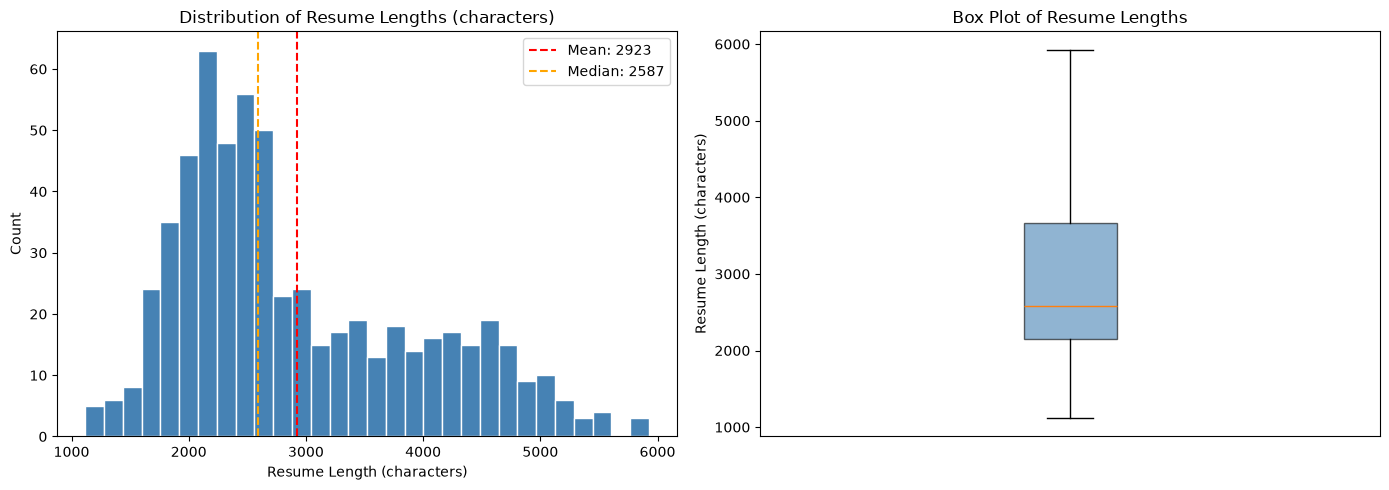

Min:      1118
Max:      5926
Mean:     2923
Median:   2587
Std:      1030


In [14]:
# Checking the number of characters in each resume texts...
resume_lengths = [len(resume_text) for resume_text in df["resume_text"]]
plot_resume_data(resume_lengths)

/var/folders/d8/l1z8x_6j4qv99r7plyccwy0h0000gn/T/ipykernel_25329/2861809671.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))


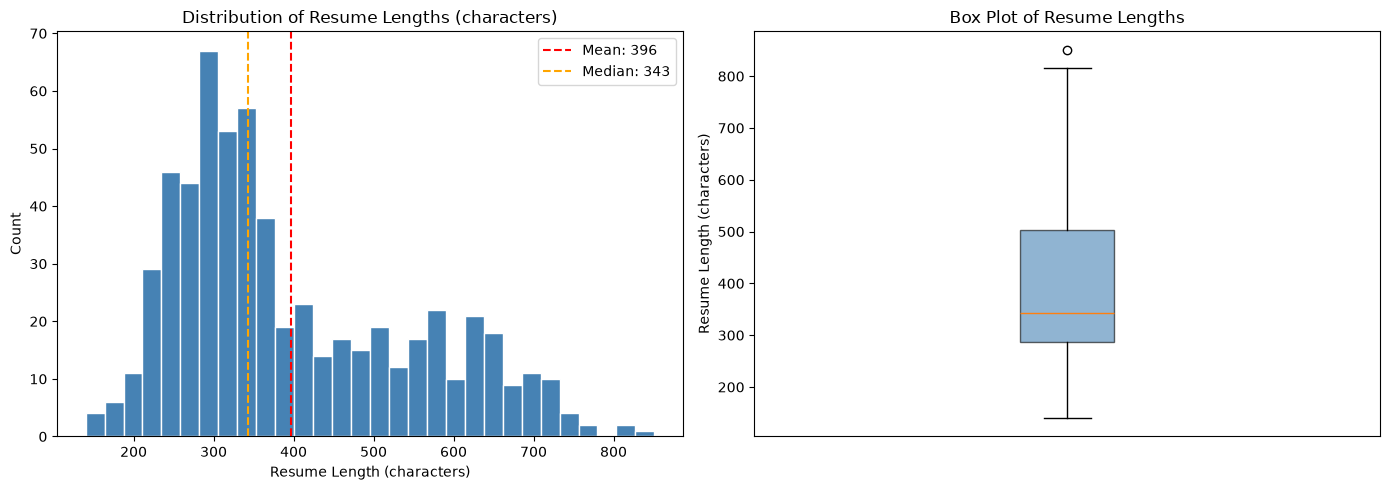

Min:       140
Max:       851
Mean:      396
Median:    343
Std:       149


In [15]:
# Checking the max number of words in each resume texts...
resume_word_counts = [len(text.split()) for text in df["resume_text"]]
plot_resume_data(resume_word_counts)

/var/folders/d8/l1z8x_6j4qv99r7plyccwy0h0000gn/T/ipykernel_25329/2861809671.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))


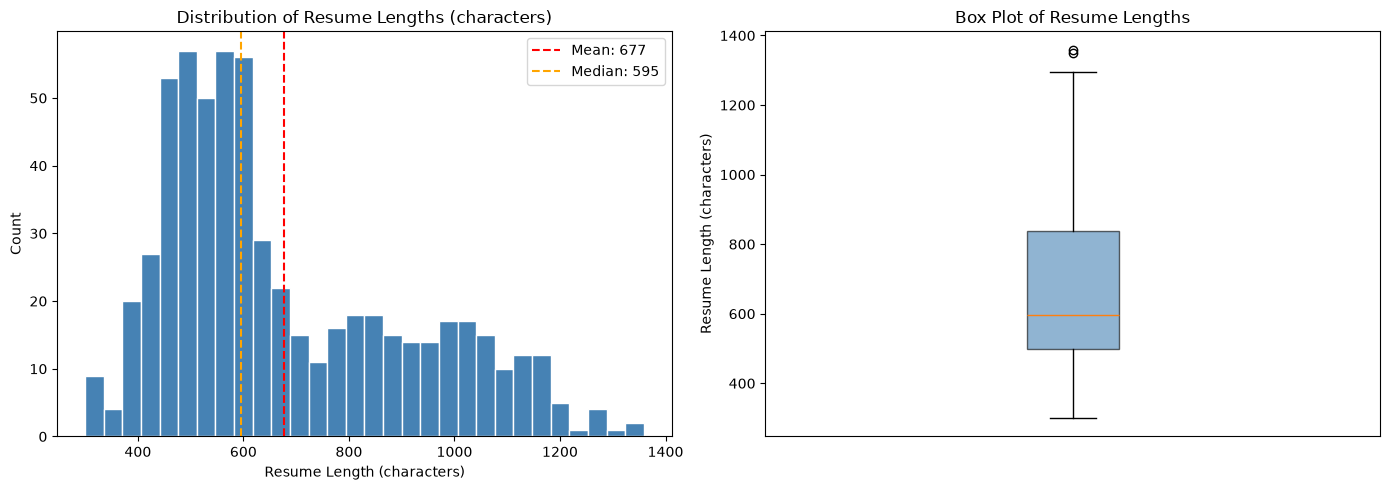

Min:       300
Max:      1359
Mean:      677
Median:    595
Std:       232


In [16]:
# Checking the max number of tokens in all the resume_text using the tokenizer from the resume scoring model...
resume_text_token_lengths = [len(tokenizer.encode(text)) for text in df["resume_text"]]
plot_resume_data(resume_text_token_lengths)

/var/folders/d8/l1z8x_6j4qv99r7plyccwy0h0000gn/T/ipykernel_25329/2861809671.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))


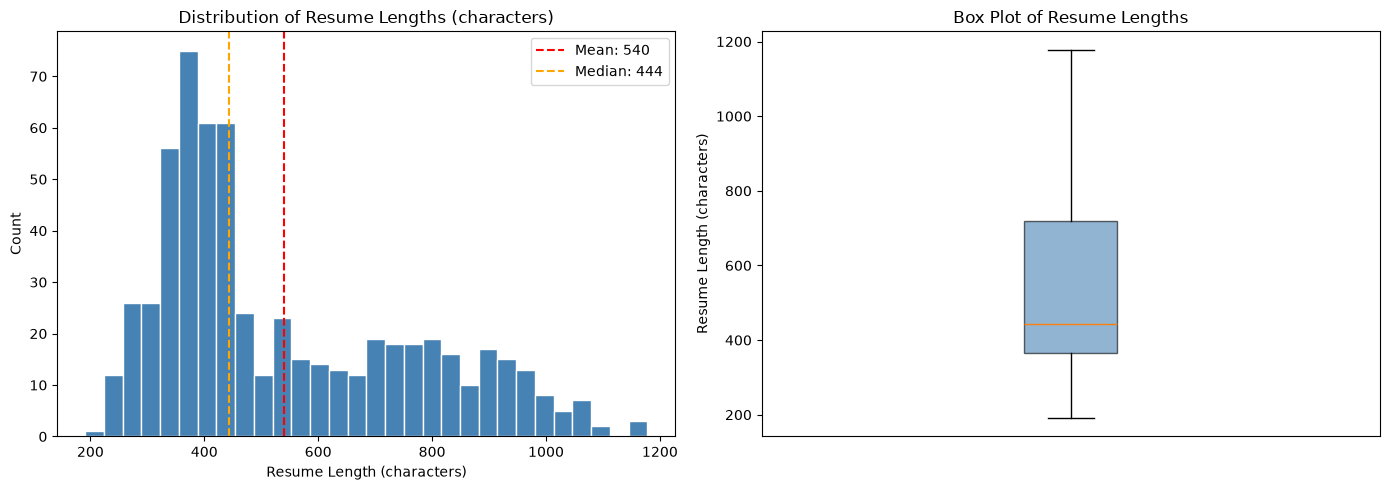

Min:       191
Max:      1178
Mean:      540
Median:    444
Std:       224


In [17]:
# Checking the max number of tokens in all the structured_json using the tokenizer from the resume scoring model...
structured_json_token_lengths = [len(tokenizer.encode(text)) for text in df["structured_json"]]
plot_resume_data(structured_json_token_lengths)

In [18]:
# Checking the length of tokens in system prompt
print(f"Length of system prompt: {len(tokenizer.encode(Constants.EXTRACTION_SYSTEM_PROMPT_TEMPLATE))} tokens")

Length of system prompt: 266 tokens


In [19]:
# Checking the length of tokens in user prompt
print(f"Length of user prompt: {len(tokenizer.encode(Constants.EXTRACTION_USER_PROMPT_TEMPLATE))} tokens")

Length of user prompt: 15 tokens


#### Analysis results:
- Total number of rows: 600
- Total number of JSONs which are not proper: 0
- Total inferred (not found in resume text): 0
- Maximum characters in resume_text: 5926
- Maximum words in resume_text: 851
- Maximum token size in resume_text: 1359
- Maximum token size in structured_json: 1178
- Number of tokens in system prompt: 261
- Number of tokens in user prompt: 15


## Creating train, validation and test datasets from the original dataset

In [20]:
def make_prompt(resume_text):
    return [
        {
            "role": "system",
            "content": Constants.EXTRACTION_SYSTEM_PROMPT_TEMPLATE
        },
        {
            "role": "user",
            "content": Constants.EXTRACTION_USER_PROMPT_TEMPLATE.replace("<resume_text>", resume_text)
        },
    ]

In [21]:
def make_prompt_with_assistant(resume_text, structured_json):
    messages = make_prompt(resume_text)
    messages.append({
        "role": "assistant",
        "content": structured_json
    })
    return messages

In [22]:
def make_message(row):
    return make_prompt_with_assistant(row["resume_text"], row["structured_json"])

In [23]:
df["messages"] = df.apply(make_message, axis=1)
final_df = df[['messages']]
final_df

,messages
0,"[{'role': 'system', 'content': 'You are a resu..."
1,"[{'role': 'system', 'content': 'You are a resu..."
2,"[{'role': 'system', 'content': 'You are a resu..."
3,"[{'role': 'system', 'content': 'You are a resu..."
4,"[{'role': 'system', 'content': 'You are a resu..."
...,...
596,"[{'role': 'system', 'content': 'You are a resu..."
597,"[{'role': 'system', 'content': 'You are a resu..."
598,"[{'role': 'system', 'content': 'You are a resu..."
599,"[{'role': 'system', 'content': 'You are a resu..."


In [24]:
final_df["messages"].iloc[0]

[{'role': 'system',
  'content': 'You are a resume parser. Extract information from the resume text provided and return it as a single valid JSON object.\nOUTPUT RULES:\n- Output ONLY the JSON object. No markdown fences, no explanations, no commentary before or after.\n- Use exactly these keys, in this order, every time.\n- For any missing string value, use an empty string "". For any missing array, use an empty array []. Never use null and never omit a key.\n- All years (year, start_year, end_year) should be in the format YYYY or "Present" if currently employed or studying.\n- Do not invent or infer any information. Only extract what is present in the resume text.\n\nSCHEMA:\n{\n  "description": "",\n  "education": [\n    {\n      "school_name": "",\n      "year": "",\n      "degree": ""\n    }\n  ],\n  "skills": [],\n  "experience": [\n    {\n      "company_name": "",\n      "start_year": "",\n      "end_year": "",\n      "descriptions": []\n    }\n  ],\n  "projects": [\n    {\n     

In [33]:
train_df, temp_df = train_test_split(final_df, random_state=42, test_size=0.2)
train_df.info()

<class 'pandas.DataFrame'>
Index: 480 entries, 9 to 102
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   messages  480 non-null    object
dtypes: object(1)
memory usage: 7.5+ KB


In [34]:
train_df

,messages
9,"[{'role': 'system', 'content': 'You are a resu..."
375,"[{'role': 'system', 'content': 'You are a resu..."
523,"[{'role': 'system', 'content': 'You are a resu..."
188,"[{'role': 'system', 'content': 'You are a resu..."
131,"[{'role': 'system', 'content': 'You are a resu..."
...,...
71,"[{'role': 'system', 'content': 'You are a resu..."
106,"[{'role': 'system', 'content': 'You are a resu..."
270,"[{'role': 'system', 'content': 'You are a resu..."
435,"[{'role': 'system', 'content': 'You are a resu..."


In [36]:
valid_df, test_df = train_test_split(temp_df, random_state=42, train_size=0.5)
valid_df.info()

<class 'pandas.DataFrame'>
Index: 60 entries, 135 to 538
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   messages  60 non-null     object
dtypes: object(1)
memory usage: 960.0+ bytes


## Saving dataset as hugging face dataset

In [37]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(valid_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})
dataset

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 480
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 60
    })
    test: Dataset({
        features: ['messages'],
        num_rows: 61
    })
})

In [44]:
# Save dataset in huggingface hub
dataset.push_to_hub(Constants.EXTRACTION_DATASET_NAME)

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/sawarni99/resume-to-json-dataset/commit/4774519875cb50153840ef3f069e92179abdf82b', commit_message='Upload dataset', commit_description='', oid='4774519875cb50153840ef3f069e92179abdf82b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sawarni99/resume-to-json-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sawarni99/resume-to-json-dataset'), pr_revision=None, pr_num=None)

## Training

#### Training is done on Kaggle
[Link](https://www.kaggle.com/code/sawarni99/resume-extraction-training-unsloth) to the colab and the model is pushed to hub.

- Base model used for finetuning: Llama-3.2-3B-Instruct
- Used unsloth FastLanguageModel for fine tuning.
- Used quantization of 4-bit with 16 rank LoRA adapter on attention layers.

Training Loss: 0.2584
<br>
Validation Loss: 0.2788
<br>
Training reports: [wandb](https://wandb.ai/sawarni/huggingface/runs/lkzdoyuk?nw=nwusersawarni99)


## Inference

In [45]:
def generate_json(messages=None, resume_text=None):
    response = "No parameters passed!"

    if(not messages and resume_text):
        messages = make_prompt(resume_text)

    if(messages):
        results = ollama.chat(
            model=Constants.EXTRACTION_FT_OLLAMA_ENDPOINT,
            messages=messages
        )
        response = results["message"]["content"]
        
    return response

In [46]:
def ollama_list():
    return [ model["model"] for model in ollama.list()["models"] ]

In [47]:
def show_json_format(text):
    print(json.dumps(json.loads(text), indent=4))

In [ ]:
if(Constants.EXTRACTION_FT_OLLAMA_ENDPOINT in ollama_list()) :
    ollama.delete(Constants.EXTRACTION_FT_OLLAMA_ENDPOINT)

ollama.pull(Constants.EXTRACTION_FT_OLLAMA_ENDPOINT)
ollama_list()

ProgressResponse(status='success', completed=None, total=None, digest=None)

In [ ]:
# sample_test = dataset["test"][14]["messages"]
# messages = sample_test[0:2]
# show_json_format(generate_json(messages=messages))

In [ ]:
# show_json_format(sample_test[2]["content"])

In [ ]:
my_resume_text = FileUtil().extract_text(file_path="/Users/mayur/Documents/My Resume/SawarniSwaroop.pdf")
show_json_format(generate_json(resume_text=my_resume_text))

{
    "description": "Results-driven Software Developer with 3+ years of experience in Spring boot, React JS, and SQL, specializing in performance optimization and cybersecurity. Skilled in solving complex problems and leading projects to success. Looking to leverage my technical expertise to drive innovation and deliver impactful software solutions in a dynamic environment.",
    "education": [
        {
            "school_name": "Karunya Institute of Technology and Science",
            "year": "2017",
            "degree": "Bachelor of Technology in Computer Science"
        }
    ],
    "skills": [
        "Java",
        "JavaScript",
        "SQL",
        "HTML",
        "CSS",
        "SpringBoot",
        "React.js",
        "Node.js",
        "SQL"
    ],
    "experience": [
        {
            "company_name": "Zoho Corp Pvt Ltd.",
            "start_year": "2021",
            "end_year": "Present",
            "descriptions": [
                "Introduced URL Monitoring f

## Evaluation